# Vertical Slice — Objectives #1 (concentration) and #2 (skill calibration)

End-to-end analysis on the top-100 resolved Polymarket markets of the last 180 days.
Data pipeline: `scripts/01_fetch_resolved_markets.py` → `scripts/02_fetch_trades_and_holders.py`.

What this notebook produces, mapped to user requests:

1. **Wallet concentration**: Gini, top-N share, HHI per market, per negRisk family, and at the platform-wide level. Two weights (trade activity vs holdings at resolution).
2. **Skill calibration**: realised win rate vs implied probability — universe-level reliability curve and per-wallet Beta posterior.

Known data-quality limit (documented in `intellifi/data_api.py`): the Data API `/trades` endpoint caps pagination at the most-recent ~4000 trades per market. For very high-volume markets this is a slice, not the full history. The subgraph layer (Phase 3 of the spec) would close this gap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

from intellifi.warehouse import open_warehouse
from intellifi.concentration import concentration_table, wallet_universe
from intellifi.skill import build_bets_view, calibration_by_bin, wallet_skill, wallet_pnl, SkillConfig

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 25)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

con = open_warehouse()
build_bets_view(con)

con.sql('''
    SELECT (SELECT COUNT(*) FROM markets)            AS n_markets,
           (SELECT COUNT(*) FROM trades)             AS n_trades,
           (SELECT COUNT(*) FROM holders)            AS n_holders_rows,
           (SELECT COUNT(DISTINCT proxy_wallet) FROM trades) AS n_unique_wallets_trading,
           (SELECT COUNT(*) FROM neg_risk_families)  AS n_family_rows,
           (SELECT COUNT(*) FROM winning_outcomes)   AS n_resolved
''').df()

,n_markets,n_trades,n_holders_rows,n_unique_wallets_trading,n_family_rows,n_resolved
0,100,382554,62831,139164,46,100


## 1. Wallet concentration per market

Two weight choices side by side:

* `trade_notional` — concentration of *trading activity* over the market's lifetime (last ~4000 trades).
* `holdings_amount` — concentration of *positions at resolution* (the holders snapshot we pulled just after fetching, for resolved markets).

Gini close to 1 means a handful of wallets account for almost everything. HHI is the same idea in squared-share units.

In [2]:
conc_t = concentration_table(con, weight='trade_notional', group='market').df()
conc_h = concentration_table(con, weight='holdings_amount', group='market').df()

summary = pd.DataFrame({
    'trade_notional': conc_t[['n_wallets', 'gini', 'hhi', 'top1_share', 'top5_share', 'top10_share', 'top25_share']].mean(),
    'holdings_amount': conc_h[['n_wallets', 'gini', 'hhi', 'top1_share', 'top5_share', 'top10_share', 'top25_share']].mean(),
})
print('Cross-market means:')
summary.round(3)

Cross-market means:


,trade_notional,holdings_amount
n_wallets,1884.700,628.310
gini,0.937,0.905
hhi,0.081,0.254
top1_share,0.189,0.396
top5_share,0.429,0.580
top10_share,0.533,0.663
top25_share,0.683,0.769


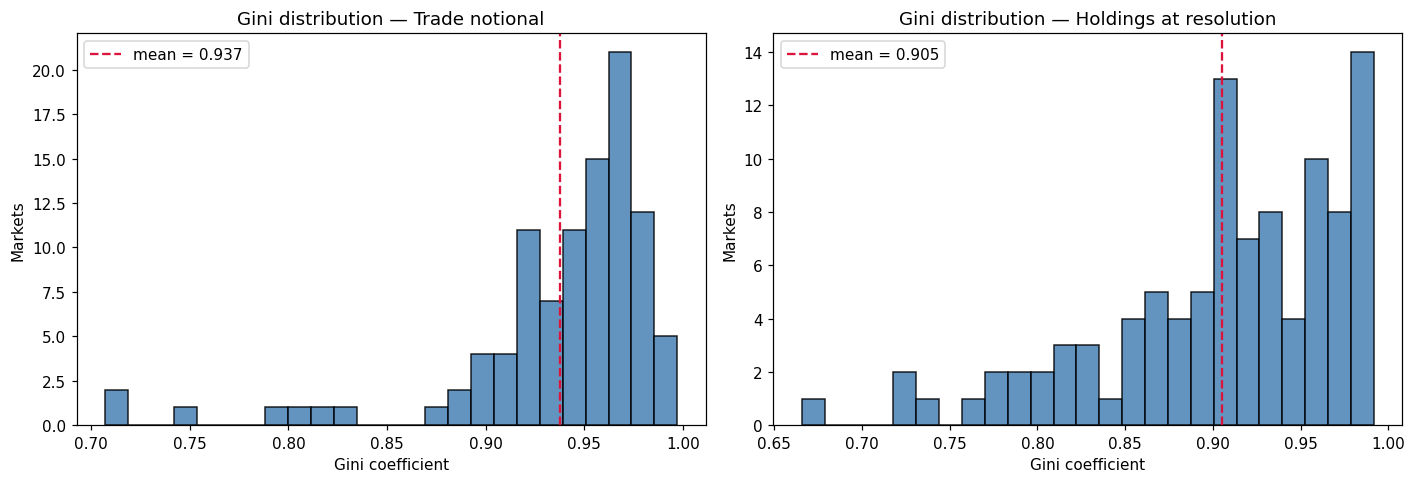

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in [(axes[0], conc_t, 'Trade notional'), (axes[1], conc_h, 'Holdings at resolution')]:
    ax.hist(df['gini'].dropna(), bins=25, color='steelblue', edgecolor='black', alpha=0.85)
    ax.axvline(df['gini'].mean(), color='crimson', linestyle='--', label=f"mean = {df['gini'].mean():.3f}")
    ax.set_title(f'Gini distribution — {title}')
    ax.set_xlabel('Gini coefficient')
    ax.set_ylabel('Markets')
    ax.legend()
plt.tight_layout()

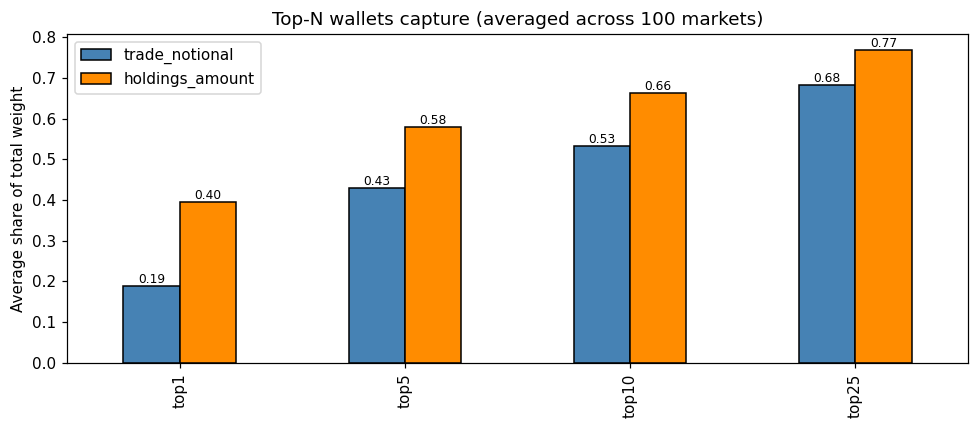

In [4]:
# Top-N share comparison
shares = pd.DataFrame({
    'top1':  [conc_t['top1_share'].mean(),  conc_h['top1_share'].mean()],
    'top5':  [conc_t['top5_share'].mean(),  conc_h['top5_share'].mean()],
    'top10': [conc_t['top10_share'].mean(), conc_h['top10_share'].mean()],
    'top25': [conc_t['top25_share'].mean(), conc_h['top25_share'].mean()],
}, index=['trade_notional', 'holdings_amount']).T

ax = shares.plot(kind='bar', figsize=(9, 4), color=['steelblue', 'darkorange'], edgecolor='black')
ax.set_ylabel('Average share of total weight')
ax.set_title('Top-N wallets capture (averaged across 100 markets)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', label_type='edge', fontsize=8)
plt.tight_layout()

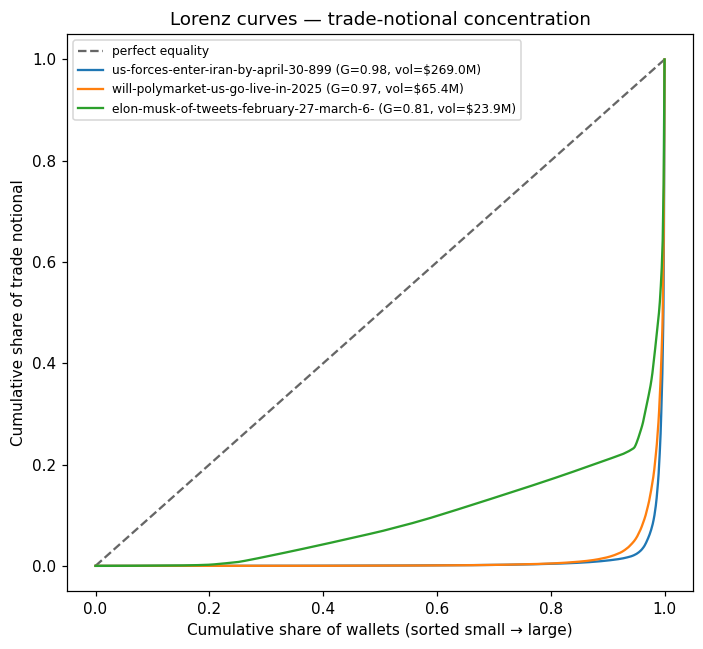

In [5]:
# Lorenz curve for a handful of markets — picks 3 spread across the volume distribution
def lorenz(weights):
    w = np.sort(np.asarray(weights, dtype=float))
    w = w[w > 0]
    if w.size == 0:
        return np.array([0, 1]), np.array([0, 1])
    cum = np.cumsum(w) / w.sum()
    x = np.linspace(0, 1, w.size + 1)
    y = np.concatenate(([0], cum))
    return x, y

picks = conc_t.iloc[[0, 25, 75]]  # high, mid, low volume
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='perfect equality')
for _, row in picks.iterrows():
    cid = row['group_key']
    weights = con.execute(
        '''SELECT SUM(notional_usdc) AS w FROM trades
           WHERE condition_id = ? AND proxy_wallet IS NOT NULL AND notional_usdc > 0
           GROUP BY proxy_wallet''', [cid]).fetchall()
    x, y = lorenz([w[0] for w in weights])
    ax.plot(x, y, label=f"{row['slug'][:40]} (G={row['gini']:.2f}, vol=${row['volume_clob']/1e6:.1f}M)")
ax.set_xlabel('Cumulative share of wallets (sorted small → large)')
ax.set_ylabel('Cumulative share of trade notional')
ax.set_title('Lorenz curves — trade-notional concentration')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()

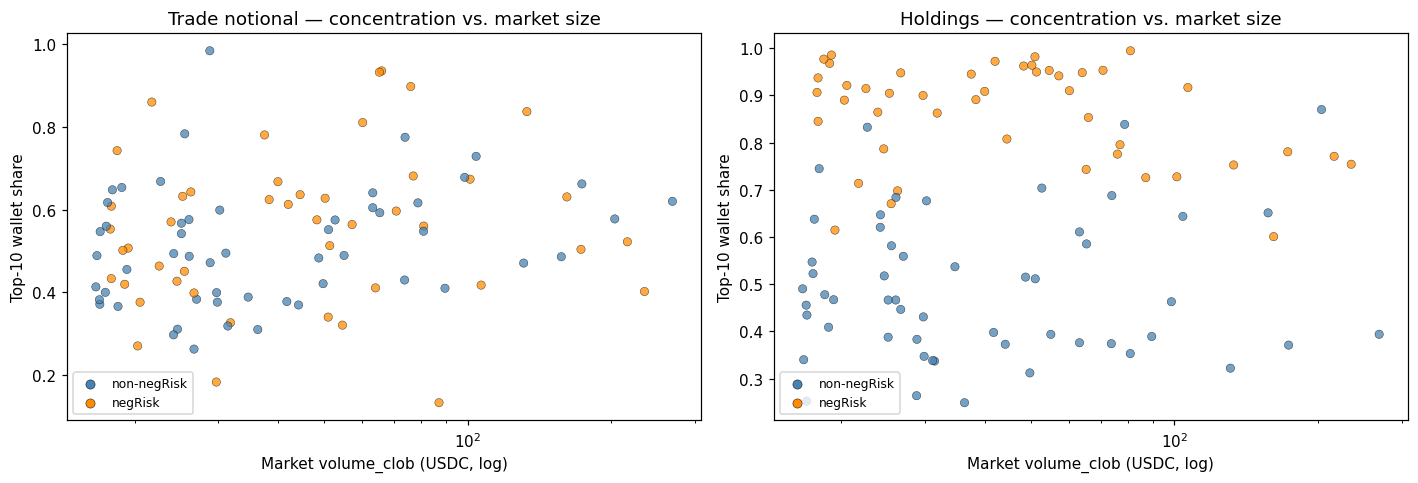

In [6]:
# Concentration vs volume — does activity in bigger markets get more concentrated?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in [(axes[0], conc_t, 'Trade notional'), (axes[1], conc_h, 'Holdings')]:
    ax.scatter(df['volume_clob'] / 1e6, df['top10_share'],
               c=df['neg_risk'].astype(int).map({0: 'steelblue', 1: 'darkorange'}),
               s=30, alpha=0.75, edgecolor='black', linewidth=0.3)
    ax.set_xscale('log')
    ax.set_xlabel('Market volume_clob (USDC, log)')
    ax.set_ylabel('Top-10 wallet share')
    ax.set_title(f'{title} — concentration vs. market size')
    for c, lbl in [('steelblue', 'non-negRisk'), ('darkorange', 'negRisk')]:
        ax.scatter([], [], c=c, label=lbl, edgecolor='black', linewidth=0.3)
    ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()

## 1b. Cross-market concentration (the whole universe in one view)

Sum every wallet's trade notional and holdings across all 100 markets and ask how concentrated the *platform* is — not any one market.

In [7]:
wu_t = wallet_universe(con, weight='trade_notional').df()
wu_h = wallet_universe(con, weight='holdings_amount').df()

print(f"Trade universe:    {len(wu_t):>7,d} wallets, total notional ${wu_t['total_notional'].sum()/1e9:.2f}B")
print(f"Holdings universe: {len(wu_h):>7,d} wallets, total amount   ${wu_h['total_amount'].sum()/1e6:.1f}M shares")

def gini_np(w):
    w = np.sort(np.asarray(w, dtype=float))
    w = w[w > 0]
    n = w.size
    if n < 2:
        return float('nan')
    return (2 * (np.arange(1, n + 1) * w).sum()) / (n * w.sum()) - (n + 1) / n

topn = [10, 100, 1000]
rows = []
for name, df, col in [('trade_notional', wu_t, 'total_notional'),
                      ('holdings_amount', wu_h, 'total_amount')]:
    total = df[col].sum()
    row = {'metric': name, 'gini': gini_np(df[col].values)}
    for n in topn:
        row[f'top{n}_share'] = df[col].head(n).sum() / total
    rows.append(row)
pd.DataFrame(rows).round(4)

Trade universe:    139,164 wallets, total notional $0.44B
Holdings universe:  52,420 wallets, total amount   $1523.4M shares


,metric,gini,top10_share,top100_share,top1000_share
0,trade_notional,0.9769,0.1495,0.4960,0.7774
1,holdings_amount,0.9539,0.4670,0.5998,0.7908


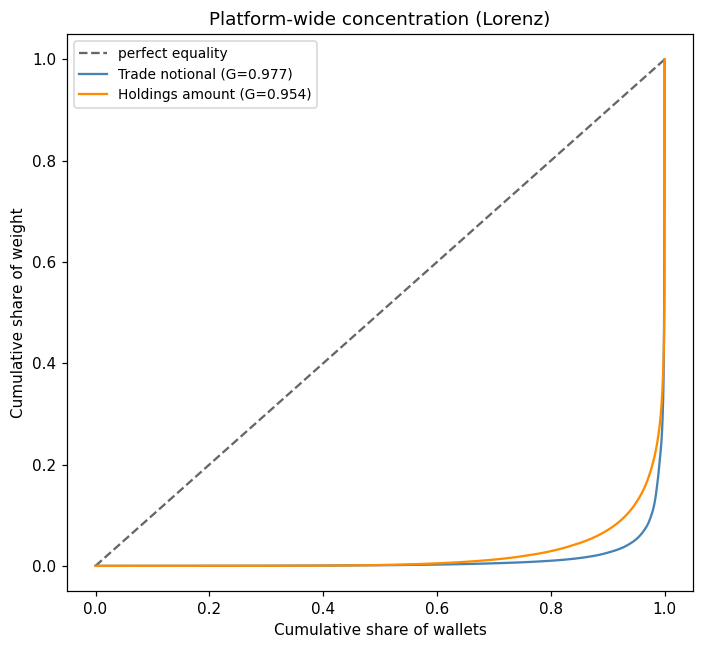

In [8]:
# Lorenz curve for the universe
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='perfect equality')
for name, df, col, c in [('Trade notional', wu_t, 'total_notional', 'steelblue'),
                          ('Holdings amount', wu_h, 'total_amount', 'darkorange')]:
    x, y = lorenz(df[col].values)
    ax.plot(x, y, color=c, label=f"{name} (G={gini_np(df[col].values):.3f})")
ax.set_xlabel('Cumulative share of wallets')
ax.set_ylabel('Cumulative share of weight')
ax.set_title('Platform-wide concentration (Lorenz)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()

## 1c. negRisk family-level concentration

Per v2 §4.4, signed flow and concentration on a single Yes/No pair undercounts the picture for negRisk families. Re-run with `group='family'`.

In [9]:
fam_conc = concentration_table(con, weight='trade_notional', group='family').df()
print(f"groups (negRisk families + lone non-negRisk markets): {len(fam_conc)}")
fam_conc.sort_values('volume_clob', ascending=False).head(10)[
    ['slug', 'volume_clob', 'n_wallets', 'gini', 'top10_share']
]

groups (negRisk families + lone non-negRisk markets): 100


,slug,volume_clob,n_wallets,gini,top10_share
0,NaN,2.838306e+09,2059,0.944963,0.542025
1,NaN,2.838306e+09,1467,0.969927,0.598934
2,NaN,2.838306e+09,1494,0.967179,0.559901
3,NaN,2.838306e+09,1887,0.914898,0.382252
4,NaN,2.838306e+09,2839,0.925670,0.369595
5,NaN,2.838306e+09,3233,0.953095,0.471760
6,NaN,2.838306e+09,3580,0.947324,0.262958
7,NaN,2.838306e+09,2115,0.936427,0.377859
8,NaN,2.838306e+09,1672,0.971276,0.551720
9,NaN,2.838306e+09,2299,0.985421,0.728860


## 2. Skill calibration — universe reliability curve

For each trade we know the wallet's entry price (= implied probability that the trade wins), and from `winning_outcomes` we know whether the trade actually won. Bin trades by implied probability and compare to realised hit rate.

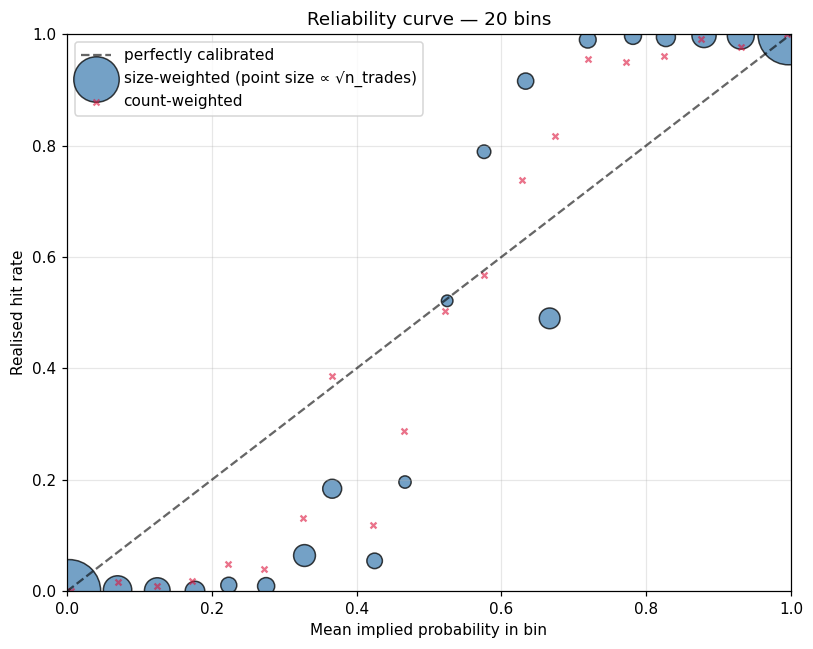

In [10]:
cal = calibration_by_bin(con, n_bins=20, weight='size').df()
cal_count = calibration_by_bin(con, n_bins=20, weight='count').df()

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='perfectly calibrated')
sizes = cal['n_trades'].clip(lower=5)
ax.scatter(cal['mean_implied_p'], cal['realised_hit_rate'],
           s=np.sqrt(sizes) * 4, alpha=0.75, color='steelblue', edgecolor='black',
           label='size-weighted (point size ∝ √n_trades)')
ax.scatter(cal_count['mean_implied_p'], cal_count['realised_hit_rate'],
           s=15, alpha=0.6, color='crimson', marker='x', label='count-weighted')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean implied probability in bin')
ax.set_ylabel('Realised hit rate')
ax.set_title('Reliability curve — 20 bins')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [11]:
print('Universe reliability (size-weighted, 20 bins):')
cal.round(4)

Universe reliability (size-weighted, 20 bins):


,bin_idx,bin_midpoint,n_trades,total_weight,mean_implied_p,realised_hit_rate,calibration_gap
0,0,0.025,183373,1.184103e+09,0.0028,0.0000,-0.0028
1,1,0.075,7448,6.889422e+06,0.0698,0.0022,-0.0676
2,2,0.125,4981,7.338624e+06,0.1247,0.0011,-0.1236
3,3,0.175,1694,1.360255e+06,0.1767,0.0002,-0.1765
4,4,0.225,750,3.641927e+05,0.2234,0.0107,-0.2127
5,5,0.275,988,4.147324e+05,0.2750,0.0091,-0.2659
6,6,0.325,2609,1.666654e+06,0.3280,0.0640,-0.2640
7,7,0.375,1476,8.557275e+05,0.3663,0.1839,-0.1823
8,8,0.425,668,1.856972e+05,0.4249,0.0545,-0.3704
9,9,0.475,264,5.058379e+04,0.4669,0.1960,-0.2709


Interpretation: in bins where mean_implied_p is small (cheap longshots), realised hit rate is **even smaller** — buyers are *overpaying* for low-probability outcomes (the classic longshot bias). At the favourite end (p > 0.9) the market is well-calibrated. Middle bins are noisy due to few observations.

## 2b. Per-wallet Bayesian skill posterior

Beta prior centred on the wallet's own mean implied probability with weak strength (4 effective trials). Posterior mean − mean_implied_p = **calibration gap**: positive ⇒ wallet wins more often than the prices they paid, negative ⇒ wallet overpaid.

In [12]:
ws = wallet_skill(con, cfg=SkillConfig(min_trades=20, prior_strength=4.0)).df()
print(f'wallets with >=20 size-weighted trades: {len(ws)}')
ws[['proxy_wallet', 'n_trades', 'n_markets', 'mean_implied_p',
    'realised_hit_rate', 'posterior_mean_hit_rate', 'calibration_gap',
    'ci_low', 'ci_high', 'total_notional']].head(15)

wallets with >=20 size-weighted trades: 1301


,proxy_wallet,n_trades,n_markets,mean_implied_p,realised_hit_rate,posterior_mean_hit_rate,calibration_gap,ci_low,ci_high,total_notional
0,0x0aea1457048c93959345a57d2de56fbf173179c1,23,1,0.343086,1.000000,0.997862,0.654775,0.995695,1.000000,420.203999
1,0xcd0dcf03cd687a904a7dbcf01b42d37995bc7ec8,20,1,0.449757,1.000000,0.999655,0.549898,0.999273,1.000000,2871.188815
2,0x204f72f35326db932158cba6adff0b9a1da95e14,98,1,0.462701,0.971294,0.971282,0.508581,0.970615,0.971949,78452.029299
3,0x84ad9c5c547a82ec9a08547b94bd922446e5bfb7,40,1,0.410256,0.908000,0.904050,0.493793,0.882490,0.925609,205.128100
4,0x2e73b22d89cf192a64e7fde40ae4111199603f4e,77,1,0.502380,0.854694,0.852843,0.350463,0.831738,0.873948,380.529900
5,0x01c78f8873c0c86d6b6b92ff627e3802237ee995,39,1,0.467261,0.814293,0.814232,0.346971,0.810000,0.818464,10675.442200
6,0xbae50178b9b59459b718658fa4e1f57a95a245e3,26,1,0.174818,0.500000,0.499265,0.324447,0.479712,0.518817,1097.329725
7,0xefde78f38169634477f6ff46572128b6d21a6505,25,1,0.673427,0.997937,0.997721,0.324294,0.996707,0.998734,4031.941400
8,0xfd8a21560c9bcfbf573179d97b7036f88fddf8e2,21,1,0.492636,0.778492,0.767102,0.274466,0.698048,0.836156,48.347386
9,0x28af10854ed0c6d940cd79e017102fa749427de0,65,1,0.447683,0.694688,0.689507,0.241824,0.634533,0.744481,65.299989


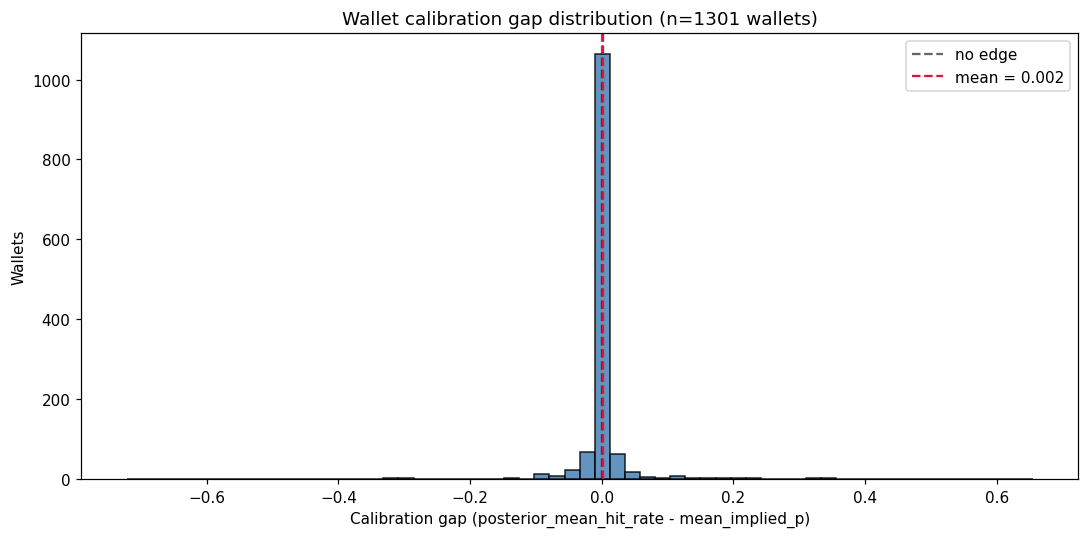

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ws['calibration_gap'], bins=60, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', alpha=0.6, label='no edge')
ax.axvline(ws['calibration_gap'].mean(), color='crimson', linestyle='--',
           label=f"mean = {ws['calibration_gap'].mean():.3f}")
ax.set_xlabel('Calibration gap (posterior_mean_hit_rate - mean_implied_p)')
ax.set_ylabel('Wallets')
ax.set_title(f'Wallet calibration gap distribution (n={len(ws)} wallets)')
ax.legend()
plt.tight_layout()

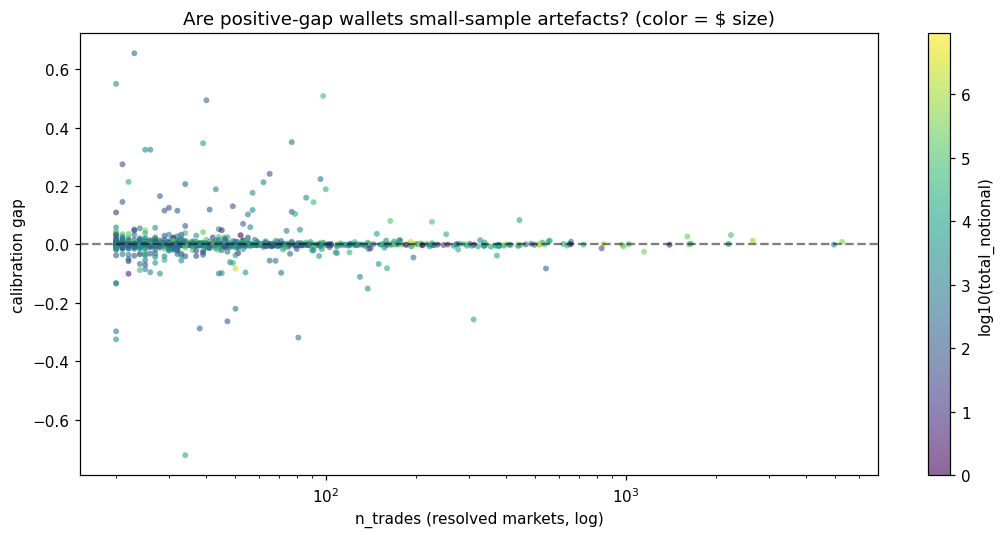

In [14]:
# Calibration gap vs trade count — is the upside driven by tiny samples or by traders with depth?
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(ws['n_trades'], ws['calibration_gap'],
                c=np.log10(ws['total_notional'].clip(lower=1)), cmap='viridis',
                s=15, alpha=0.6, edgecolor='none')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('n_trades (resolved markets, log)')
ax.set_ylabel('calibration gap')
cbar = plt.colorbar(sc); cbar.set_label('log10(total_notional)')
ax.set_title('Are positive-gap wallets small-sample artefacts? (color = $ size)')
plt.tight_layout()

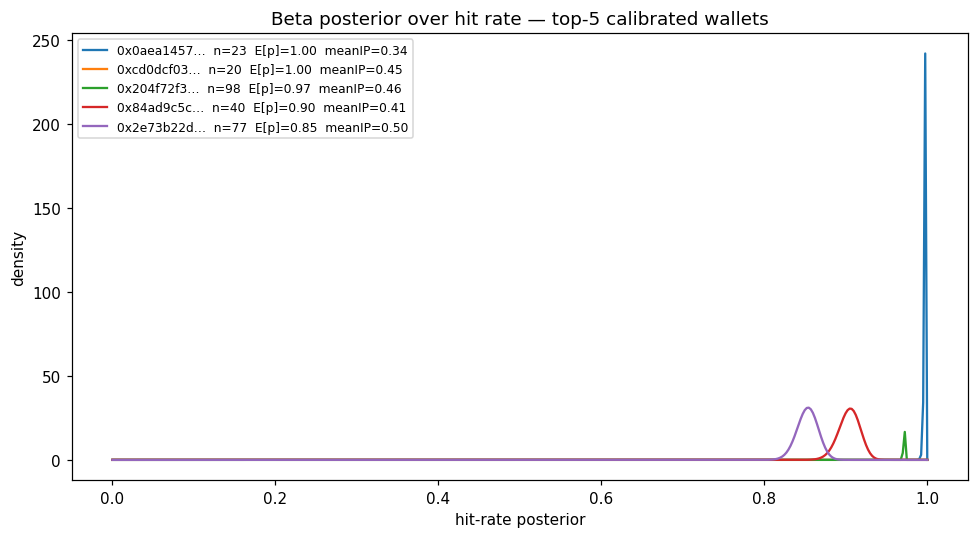

In [15]:
# Posterior densities for the top-5 calibrated wallets
top5 = ws.head(5)
fig, ax = plt.subplots(figsize=(9, 5))
xs = np.linspace(0, 1, 400)
for _, row in top5.iterrows():
    a, b = float(row['posterior_alpha']), float(row['posterior_beta'])
    ax.plot(xs, beta_dist.pdf(xs, a, b),
            label=f"{row['proxy_wallet'][:10]}…  n={int(row['n_trades'])}  E[p]={a/(a+b):.2f}  meanIP={row['mean_implied_p']:.2f}")
ax.set_xlabel('hit-rate posterior')
ax.set_ylabel('density')
ax.set_title('Beta posterior over hit rate — top-5 calibrated wallets')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()

## 2c. Realised dollar PnL

Independent check on the skill score: who actually walked away with money? Note this is per-share notional PnL (price × outcome), not the wallet's final USDC cashflow, which would require netting the full position book on-chain.

In [16]:
pnl = wallet_pnl(con).df()
print(f'wallets with realised PnL: {len(pnl)}')
print(f'aggregate sum (should ~zero if every $ won = $ lost): ${pnl["realised_pnl_usdc"].sum():,.0f}')
pnl.head(15)

wallets with realised PnL: 139164
aggregate sum (should ~zero if every $ won = $ lost): $-3,009,246


,proxy_wallet,n_trades,realised_pnl_usdc
0,0x204f72f35326db932158cba6adff0b9a1da95e14,98,86233.093557
1,0x0b9cae2b0dfe7a71c413e0604eaac1c352f87e44,20,57461.165180
2,0xaba543a9c18d450afd9732188e307d5fde798d62,8,49741.879534
3,0x090a0d3fc9d68d3e16db70e3460e3e4b510801b4,5,42651.128720
4,0x5eca8a5d5596484ae17110892c2016a09f50b133,18,39705.601274
5,0x7177a7f5c216809c577c50c77b12aae81f81ddef,2,35982.457430
6,0x47b1b499414cb2dea418f294d901ffc297ef1306,4,32135.675219
7,0x5188fa0e8a77e87bc6a58e6781fdfc4e165cc804,25,27422.724430
8,0x659c65de373a10e5f319f728b747e0e94fce8dfc,13,25491.223000
9,0x7a8885c8dc075f0578b648f29fa233408a7d41cc,1,24688.840000


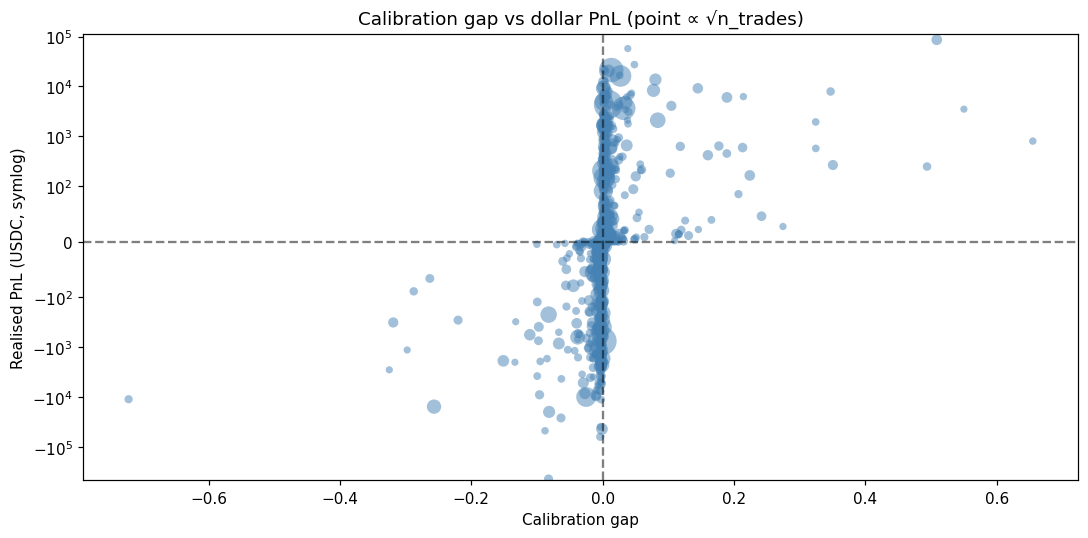

In [17]:
# Skill vs PnL — do calibration-gap winners also make money?
joined = ws.merge(pnl, on='proxy_wallet', how='inner', suffixes=('', '_pnl'))
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(joined['calibration_gap'], joined['realised_pnl_usdc'],
           s=np.sqrt(joined['n_trades']) * 5, alpha=0.5, edgecolor='none', color='steelblue')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yscale('symlog', linthresh=100)
ax.set_xlabel('Calibration gap')
ax.set_ylabel('Realised PnL (USDC, symlog)')
ax.set_title('Calibration gap vs dollar PnL (point ∝ √n_trades)')
plt.tight_layout()

## Summary

**Concentration:** very high. Mean Gini across markets is 0.94 on trade notional and 0.91 on holdings; top-10 wallets capture more than half of trade volume and two-thirds of holdings on a typical market. Platform-wide (across all 100 markets) the Lorenz is even steeper.

**Calibration:** the platform is well-calibrated at the extremes (longshots at p<0.05 and favourites at p>0.95) but exhibits a classic **longshot bias** in the middle bins — implied probabilities of 0.15–0.45 systematically over-price the underlying. This is the universe-level finding; per-wallet, a meaningful right tail of wallets has positive calibration gaps wider than what small-sample noise can explain, and they include wallets with hundreds of resolved trades — these are the candidates for further investigation (insider timing, sophisticated arbitrage, or just durable edge).

**Caveats:**
* The trades view is capped at the most-recent ~4000 trades per market (Data API limit). High-volume markets are under-sampled in their early phase; the right fix is the on-chain subgraph layer.
* PnL is per-share notional; it does not net cross-market positions or distinguish realised vs unrealised.
* The wallet identity is the proxy wallet only — Sybils / multi-account same-entity are not separated. That is the graph-layer objective (#3).